In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


In [3]:
symbol = 'A'
train_label = 5
train_end_date = '2025-01-01'

folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'A',
 'contract_multiplier': 10,
 'price_tick': 1,
 'margin_rate': 0.07,
 'fee': 2,
 'fee_way': 'number',
 'fee_comment': '无',
 'trading_hours': ['09:00-11:30', '13:30-15:00', '21:00-23:00'],
 'light': 1,
 'night': 1,
 'exchange': 'dce',
 'name': '豆一'}

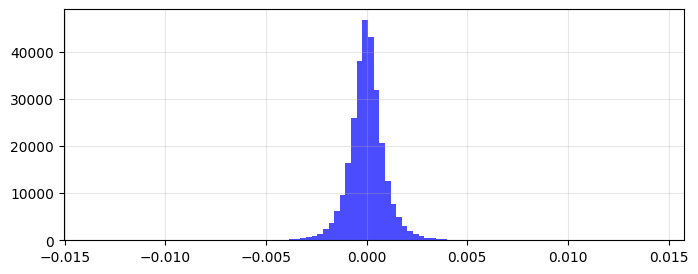

2025-01-01_A_5


In [4]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

In [5]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0.5},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            'JC1D', 'ZCpriceinterval', 'ptvol5', 'term_rtn'
            'JC2H'
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(_P|P_|_M|M_|A_|_A|_OI|OI_|_Y|Y_|_RM|RM_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['pred_ret']
特征分布性过滤：
筛选之前因子数量：1866， 筛选之后因子数量：1781

特征重要性过滤： 300 200 	待筛因子个数 1781
无向因子有效个数： 886 有向因子有效个数： 961
  选择有向特征 187 个，重要性范围: 1556.00 - 45.00
  选择无向特征 135 个，重要性范围: 2284.00 - 102.00

单因子sharpe过滤： 0.5 sp范围-6.192 ~ 5.7421   待筛因子个数 322

特征相关性性过滤： 300     待筛因子个数 277
  选择特征 230 个, 特征最大相关性0.8992326997106772

已挑选日频开盘因子数量： 4 ['day_first4redcorr', 'day_jump', 'day_first10rev', 'day_first10colarrate']

排除指定因子后，剩余特征 230 个


(167, 0, 36, 27)

正在从 /mnt/Data/writable/liaoyuyang/factor/A/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (284126, 1870)
训练集时间范围: 2021-02-02 09:11:00 至 2024-12-31 14:49:00
[200]	valid_0's rmse: 0.993953
[400]	valid_0's rmse: 0.994006
[600]	valid_0's rmse: 0.994259


<Figure size 1000x600 with 0 Axes>

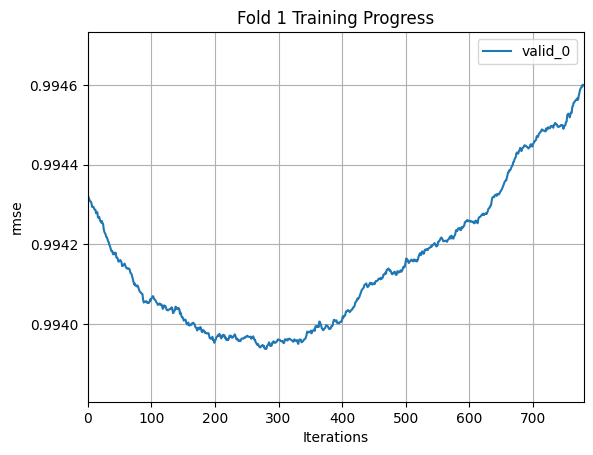

{'train_rmse': np.float64(0.996211405762), 'val_rmse': np.float64(0.9996355836293939), 'best_iteration': 280}
test_corr: 0.0088
[200]	valid_0's rmse: 0.994028
[400]	valid_0's rmse: 0.994075
[600]	valid_0's rmse: 0.994198


<Figure size 1000x600 with 0 Axes>

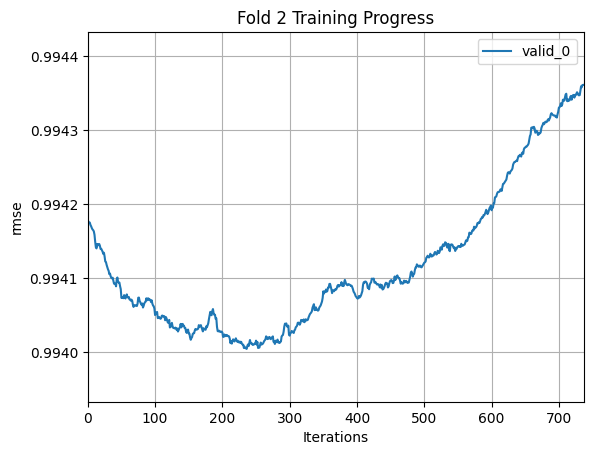

{'train_rmse': np.float64(0.996297344417179), 'val_rmse': np.float64(0.9998449010862157), 'best_iteration': 237}
test_corr: 0.0017
[200]	valid_0's rmse: 0.993983
[400]	valid_0's rmse: 0.993852
[600]	valid_0's rmse: 0.993756
[800]	valid_0's rmse: 0.993739
[1000]	valid_0's rmse: 0.993714
[1200]	valid_0's rmse: 0.993675
[1400]	valid_0's rmse: 0.993699
[1600]	valid_0's rmse: 0.993722


<Figure size 1000x600 with 0 Axes>

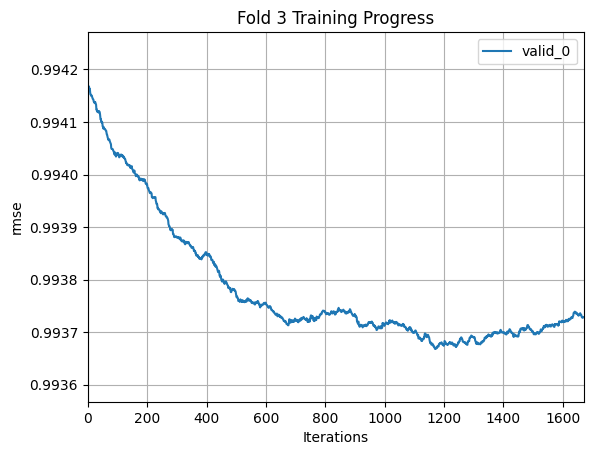

{'train_rmse': np.float64(0.9856271128076785), 'val_rmse': np.float64(0.9994972118810729), 'best_iteration': 1171}
test_corr: 0.0053
[200]	valid_0's rmse: 0.994051
[400]	valid_0's rmse: 0.994014
[600]	valid_0's rmse: 0.993991
[800]	valid_0's rmse: 0.993992
[1000]	valid_0's rmse: 0.994032


<Figure size 1000x600 with 0 Axes>

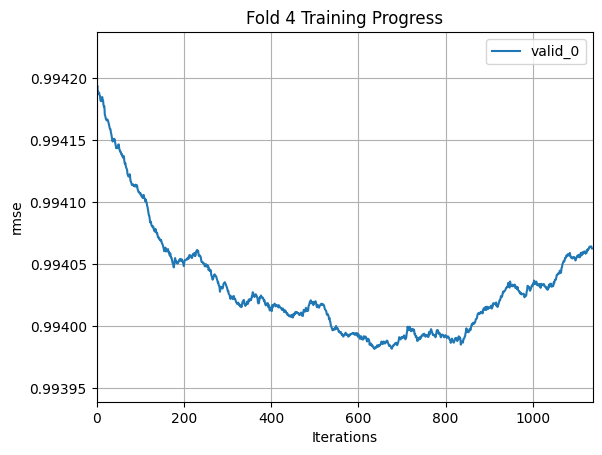

{'train_rmse': np.float64(0.9914399571093272), 'val_rmse': np.float64(0.999786629992863), 'best_iteration': 637}
test_corr: 0.0029
[200]	valid_0's rmse: 0.994286
[400]	valid_0's rmse: 0.994272
[600]	valid_0's rmse: 0.994292
[800]	valid_0's rmse: 0.994274


<Figure size 1000x600 with 0 Axes>

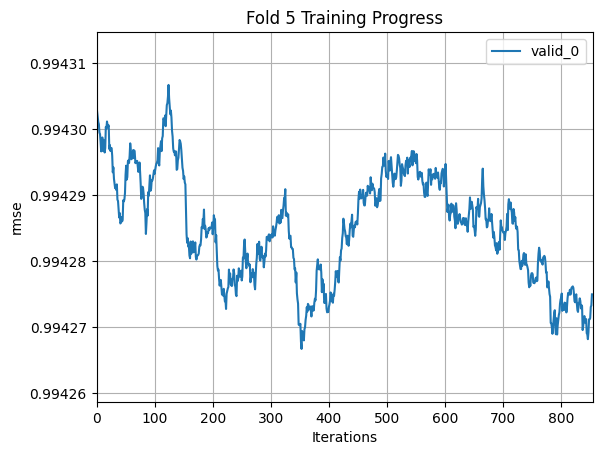

{'train_rmse': np.float64(0.9948492218612598), 'val_rmse': np.float64(1.0000913751393163), 'best_iteration': 354}
test_corr: 0.0036


In [6]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [7]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/A_pred5_2025-01-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [8]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 200_000 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [9]:
merged_data = bt.backtest(th1=0.9, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*345, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/103618 [00:00<?, ?it/s]

In [10]:
merged_data

,datetime,factor,pos,close,tick6t60avg,th_open_long,th_close_long,th_open_short,th_close_short,date,...,Margin_rate,pnl_ret,pnl_ret_cum,cost&slippage_cum,cost&slippage_rate,month,year,th1,th2,date_cum_ret
0,2025-01-02 09:01:00,0.001301,0.0,3935.0,3936.711628,0.025068,0.001652,-0.011335,0.001652,2025-01-02,...,NaN,0.0,0.0000,0.0,0.0,2025-01,2025,0.9,0.5,0.000000
1,2025-01-02 09:02:00,-0.016666,0.0,3935.0,3931.276699,0.025068,0.001652,-0.011335,0.001652,2025-01-02,...,NaN,0.0,0.0000,0.0,0.0,2025-01,2025,0.9,0.5,0.000000
2,2025-01-02 09:03:00,-0.030036,0.0,3942.0,3939.159420,0.025068,0.001652,-0.011335,0.001652,2025-01-02,...,0.0,0.0,0.0000,0.0,NaN,2025-01,2025,0.9,0.5,0.000000
3,2025-01-02 09:04:00,-0.024496,0.0,3950.0,3948.046948,0.025068,0.001652,-0.011335,0.001652,2025-01-02,...,0.0,0.0,0.0000,0.0,NaN,2025-01,2025,0.9,0.5,0.000000
4,2025-01-02 09:05:00,-0.023722,0.0,3946.0,3949.075758,0.025068,0.001652,-0.011335,0.001652,2025-01-02,...,0.0,0.0,0.0000,0.0,NaN,2025-01,2025,0.9,0.5,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103615,2026-04-08 14:56:00,-0.003286,0.0,4612.0,4612.258824,0.013737,0.001467,-0.008297,0.001467,2026-04-08,...,0.0,0.0,-0.0188,0.0,NaN,2026-04,2026,0.9,0.5,0.024308
103616,2026-04-08 14:57:00,-0.001840,0.0,4613.0,4612.282759,0.013737,0.001439,-0.008297,0.001439,2026-04-08,...,0.0,0.0,-0.0188,0.0,NaN,2026-04,2026,0.9,0.5,0.024308
103617,2026-04-08 14:58:00,-0.007759,0.0,4614.0,4613.280822,0.013737,0.001429,-0.008297,0.001429,2026-04-08,...,0.0,0.0,-0.0188,0.0,NaN,2026-04,2026,0.9,0.5,0.024308
103618,2026-04-08 14:59:00,-0.003689,0.0,4616.0,4614.616438,0.013737,0.001429,-0.008297,0.001429,2026-04-08,...,0.0,0.0,-0.0188,0.0,NaN,2026-04,2026,0.9,0.5,0.024308


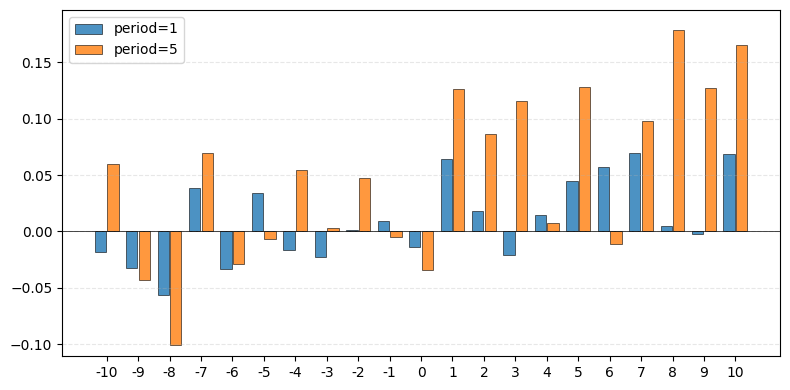

In [11]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-23:00"], g=21)

In [12]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,21806
空头(-1) 数量,20450
空仓(0) 数量,61364
多头占比,21.04%
空头占比,19.74%
空仓占比,59.22%
交易日数量,305
总收益(非年化%),-1.88
总交易次数（开平算一次）,2707
日均交易次数（开平算一次）,8.88


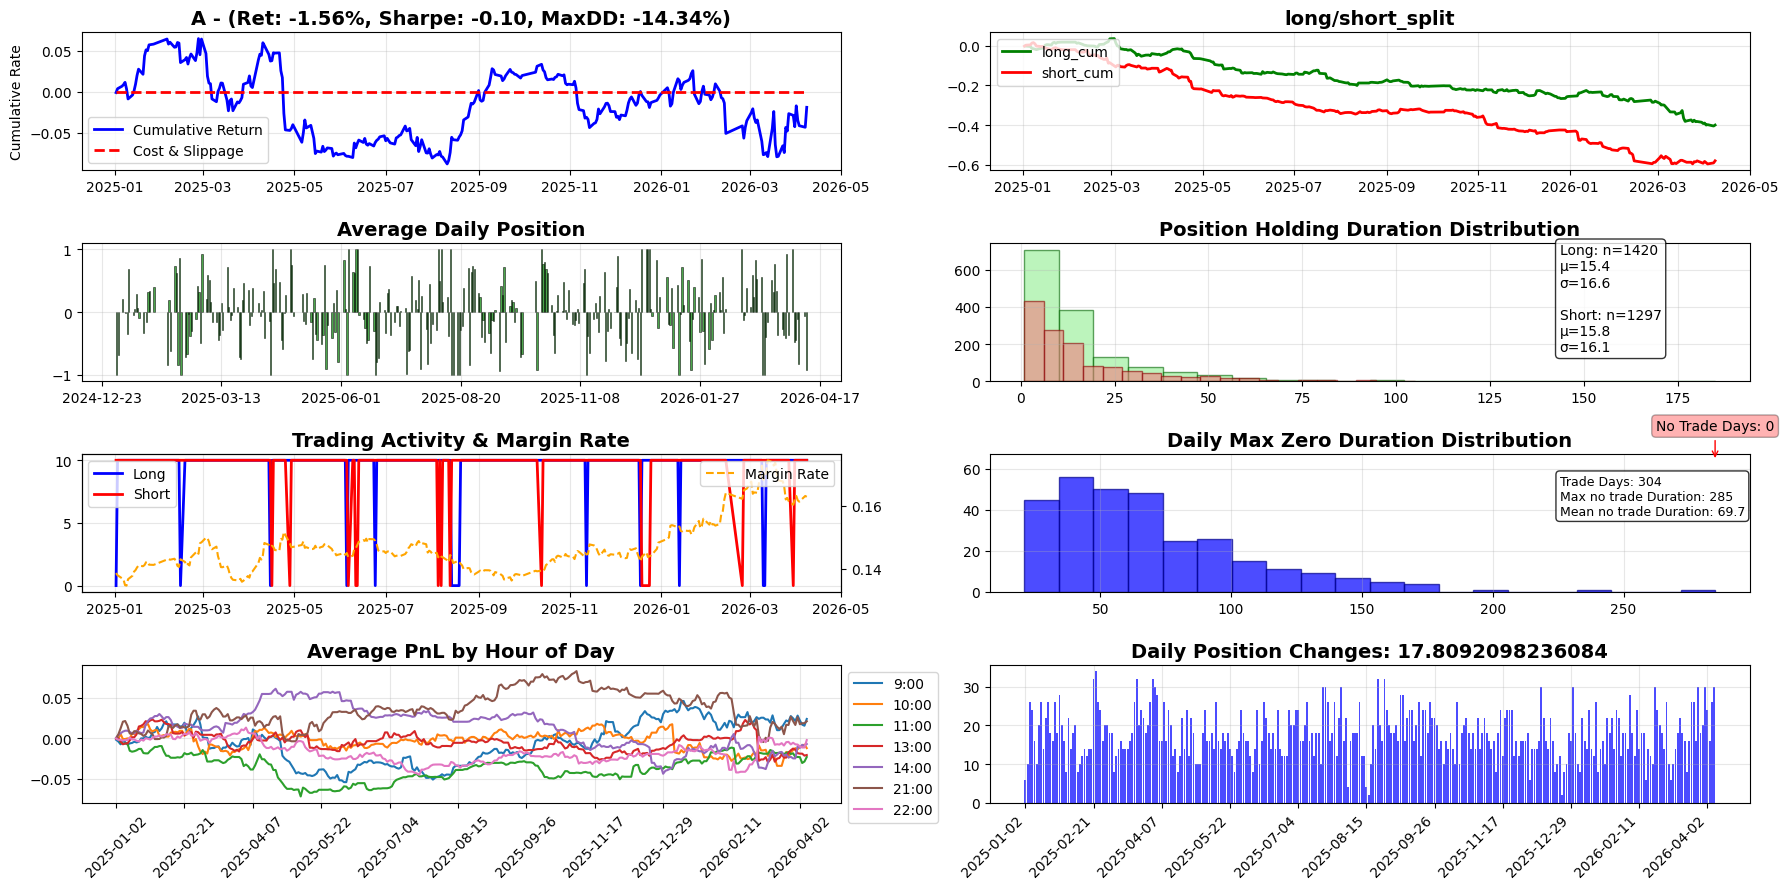

In [13]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [14]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

✅ 交易可视化工具已启动
📈 品种: A
📅 总交易日数: 304
📊 总数据点: 110352
🎯 使用导航按钮或输入页码进行浏览


In [15]:
bv.plot_yearly_eval(merged_data)